In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cirq

import stim
from stimcirq import cirq_circuit_to_stim_circuit

import pymatching

from encoded.utils import cirq_pauli_string_to_stim
from encoded.repetition_code import encoding_repetition
from encoded.expanded_repetition_code import (
    x_bar,
    z_bar,
    stabilizer_generators,
    encoding_expanded_repetition
)

In [2]:
mode = 'X' # Whether to perform an X or Z experiment.

## Test a physical qubit

In [3]:

def physical_qubit_memory_circuit(p_depol: float):
    circuit = stim.Circuit()
    if mode == 'X':
        circuit.append("H", 0)
        circuit.append("Z_ERROR", 0, arg=p_depol)
        circuit.append("MX", 0)
    else:
        circuit.append("X_ERROR", 0, arg=p_depol)
        circuit.append("MZ", 0)
    return circuit

In [4]:
error_rates = np.linspace(1e-4, 1.0, num=10)
num_shots = 10_000
physical_err_rates = np.zeros(error_rates.size)
for i, error_rate in enumerate(error_rates):
    ckt = physical_qubit_memory_circuit(error_rate)
    sampler = ckt.compile_sampler()
    result = sampler.sample(num_shots)
    physical_err_rates[i] = np.sum(result) / num_shots

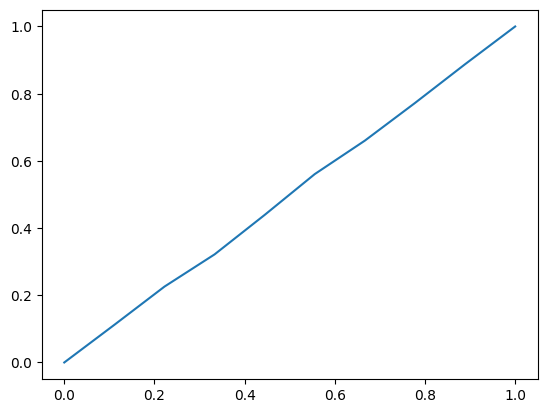

In [5]:
fig, ax = plt.subplots()
ax.plot(error_rates, physical_err_rates)

## Test a logical qubit

In [6]:
qs = cirq.LineQubit.range(4)
generators = stabilizer_generators
for generator in generators:
    print(generator)

Z(q(0))*Z(q(1))
Z(q(1))*Z(q(2))
X(q(0))*X(q(1))*X(q(2))*X(q(3))


In [7]:
def pstring_to_circuit(ps: stim.PauliString):
    circuit = stim.Circuit()
    w1 = 1.0 - 1e-4
    w2 = 1e-4 / 2
    for i, p in enumerate(ps):
        if p == 1:
            # circuit.append("X", i)
            circuit.append_from_stim_program_text(f"PAULI_CHANNEL_1({w1}, {w2}, {w2}) {i}")
        elif p == 2:
            # circuit.append("Y", i)
            circuit.append_from_stim_program_text(f"PAULI_CHANNEL_1({w2}, {w1}, {w2}) {i}")
        elif p == 3:
            # circuit.append("Z", i)
            circuit.append_from_stim_program_text(f"PAULI_CHANNEL_1({w2}, {w2}, {w1}) {i}")
        else:
            continue
    return circuit

In [8]:
print(pstring_to_circuit(stim.PauliString("XIIIZY")))

PAULI_CHANNEL_1(0.9999, 5e-05, 5e-05) 0
PAULI_CHANNEL_1(5e-05, 5e-05, 0.9999) 4
PAULI_CHANNEL_1(5e-05, 0.9999, 5e-05) 5


In [9]:
def expanded_repetition_circuit_memory_z(p_depol: float, error_ratio: float, injected_error=None):
    """Circuit for a memory experiment with the expanded repetition code.
    
    Arguments:
    p_depol: Probability of a depolarizing errors on the original three qubits.
    error_ratio: Ratio of error probability of the fourth qubit to the other three (p_depol).
    
    Returns:
    A memory experiment circuit."""

    generator_ckt = stim.Circuit()
    for generator in generators:
        generator_ckt.append("MPP", cirq_pauli_string_to_stim(generator, qs))
    
    noise_ckt = stim.Circuit()
    if mode == 'X':
        noise_ckt.append("Z_ERROR", [0, 1, 2], arg=p_depol)
        noise_ckt.append("Z_ERROR", 3, arg=error_ratio * p_depol)
    else:
        noise_ckt.append("X_ERROR", [0, 1, 2], arg=p_depol)
        noise_ckt.append("X_ERROR", 3, arg=error_ratio * p_depol)

    circuit = stim.Circuit()
    # Prepare the logical state.
    if mode == 'X':
        prep_state = '+'
    else:
        prep_state = '0'
    encoding_cirq, _ = encoding_expanded_repetition(prep_state)
    circuit += cirq_circuit_to_stim_circuit(encoding_cirq)
    # Do transversal initialization.
    circuit += generator_ckt
    for i in range(3):
        circuit.append_from_stim_program_text(f"DETECTOR rec[{-i - 1}]")
    circuit.append("TICK")
    # Subject the qubits to noise, then do a round of syndrome measurement.
    if injected_error is None:
        circuit += noise_ckt
    else:
        circuit.append(pstring_to_circuit(injected_error))
    circuit += generator_ckt
    for i in range(3):
        circuit.append_from_stim_program_text(f"DETECTOR rec[{-i - 1}] rec[{-i - 1 - 3}]")
    # Measure logical Z as the observable for the experiment.
    if mode == 'X':
        circuit.append("MPP", cirq_pauli_string_to_stim(x_bar, qs))
    else:
        circuit.append("MPP", cirq_pauli_string_to_stim(z_bar, qs))
    circuit.append_from_stim_program_text("OBSERVABLE_INCLUDE(0) rec[-1]")
    return circuit

In [10]:
circuit = expanded_repetition_circuit_memory_z(0.1, 1e-2)
print(circuit)

H 0
TICK
CX 0 1
TICK
CX 1 2
TICK
H 0 1 2
TICK
CX 0 3
TICK
CX 1 3
H 0
TICK
CX 2 3
H 1
TICK
H 2 3
TICK
MPP Z0*Z1 Z1*Z2 X0*X1*X2*X3
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
TICK
Z_ERROR(0.1) 0 1 2
Z_ERROR(0.001) 3
MPP Z0*Z1 Z1*Z2 X0*X1*X2*X3
DETECTOR rec[-1] rec[-4]
DETECTOR rec[-2] rec[-5]
DETECTOR rec[-3] rec[-6]
MPP X0*X1*X2
OBSERVABLE_INCLUDE(0) rec[-1]


In [11]:
sampler = circuit.compile_detector_sampler()
result = sampler.sample(10)
print(result)

[[False False False False False False]
 [False False False False False False]
 [False False False  True False False]
 [False False False False False False]
 [False False False False False False]
 [False False False  True False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]
 [False False False False False False]]


In [12]:
detector_error_model = circuit.detector_error_model(decompose_errors=True)
print(detector_error_model)

error(0.001) D3
error(0.244) D3 L0
detector D0
detector D1
detector D2
detector D4
detector D5


In [13]:
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    detector_error_model = circuit.detector_error_model(decompose_errors=True, approximate_disjoint_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predicted_for_shot = predictions[shot]
        if not np.array_equal(actual_for_shot, predicted_for_shot):
            num_errors += 1
    return num_errors

In [14]:
print(count_logical_errors(circuit, num_shots))

2414


In [432]:
lers = np.zeros(error_rates.shape)
for i, error_rate in enumerate(error_rates):
    circuit = expanded_repetition_circuit_memory_z(error_rate, 1e-4)
    num_errs = count_logical_errors(circuit, num_shots)
    print(f"Got {num_errs} logical errors.")
    lers[i] = float(num_errs) / num_shots

Got 2 logical errors.
Got 2724 logical errors.
Got 4107 logical errors.
Got 4852 logical errors.
Got 4983 logical errors.
Got 5110 logical errors.
Got 5204 logical errors.
Got 5860 logical errors.
Got 7411 logical errors.
Got 10000 logical errors.


In [433]:
circuit = expanded_repetition_circuit_memory_z(1e-2, 1e-4)
count_logical_errors(circuit, 10)

0

## Traditional repetition code

In [434]:
def repetition_circuit_memory_z(p_depol: float, injected_error=None):
    generator_ckt = stim.Circuit()
    repetition_generators = [
        stim.PauliString("ZZI"), stim.PauliString("IZZ")
    ]
    for generator in repetition_generators:
        generator_ckt.append("MPP", generator)
    
    noise_ckt = stim.Circuit()
    if mode == 'X':
        noise_ckt.append("Z_ERROR", [0, 1, 2], arg=p_depol)
    else:
        noise_ckt.append("X_ERROR", [0, 1, 2], arg=p_depol)

    circuit = stim.Circuit()
    # Prepare the logical |0> state.
    if mode == 'X':
        prep_state = '+'
    else:
        prep_state = '0'
    encoding_cirq, _ = encoding_repetition(prep_state, 3)
    circuit += cirq_circuit_to_stim_circuit(encoding_cirq)
    # Do transversal initialization.
    circuit += generator_ckt
    for i in range(2):
        circuit.append_from_stim_program_text(f"DETECTOR rec[{-i - 1}]")
    circuit.append("TICK")
    # Subject the qubits to noise, then do a round of syndrome measurement.
    if injected_error is None:
        circuit += noise_ckt
    else:
        circuit.append(pstring_to_circuit(injected_error))
    circuit += generator_ckt
    for i in range(2):
        circuit.append_from_stim_program_text(f"DETECTOR rec[{-i - 1}] rec[{-i - 1 - 2}]")
    # Measure logical Z as the observable for the experiment.
    if mode == 'X':
        circuit.append("MPP", stim.PauliString("XXX"))
    else:
        circuit.append("MPP", stim.PauliString("ZII"))
    circuit.append_from_stim_program_text("OBSERVABLE_INCLUDE(0) rec[-1]")
    return circuit

In [435]:
circuit = repetition_circuit_memory_z(0.1)
print(circuit)

H 0
TICK
CX 0 1
TICK
CX 1 2
TICK
MPP Z0*Z1 Z1*Z2
DETECTOR rec[-1]
DETECTOR rec[-2]
TICK
Z_ERROR(0.1) 0 1 2
MPP Z0*Z1 Z1*Z2
DETECTOR rec[-1] rec[-3]
DETECTOR rec[-2] rec[-4]
MPP X0*X1*X2
OBSERVABLE_INCLUDE(0) rec[-1]


In [436]:
lers_repetition = np.zeros(error_rates.shape)
for i, error_rate in enumerate(error_rates):
    circuit = repetition_circuit_memory_z(error_rate)
    num_errs = count_logical_errors(circuit, num_shots)
    print(f"Got {num_errs} logical errors.")
    lers_repetition[i] = float(num_errs) / num_shots

Got 6 logical errors.
Got 2634 logical errors.
Got 4129 logical errors.
Got 4792 logical errors.
Got 5012 logical errors.
Got 4891 logical errors.
Got 5130 logical errors.
Got 5836 logical errors.
Got 7337 logical errors.
Got 10000 logical errors.


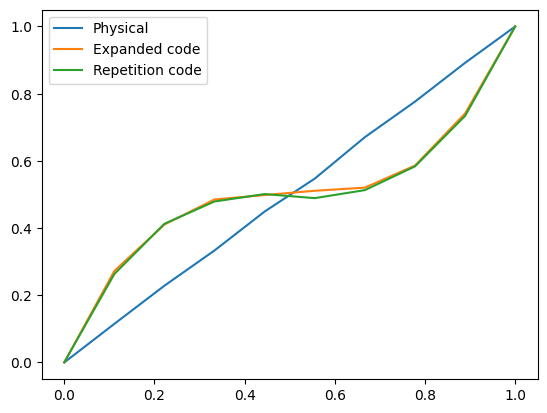

In [437]:
fig, ax = plt.subplots()
ax.plot(error_rates, physical_err_rates, label="Physical")
ax.plot(error_rates, lers, label="Expanded code")
ax.plot(error_rates, lers_repetition, label="Repetition code")
ax.legend()

## Try injecting errors

In [20]:
circuit = expanded_repetition_circuit_memory_z(0.3, 1e-2, stim.PauliString("ZZZI"))
print(circuit)

H 0
TICK
CX 0 1
TICK
CX 1 2
TICK
H 0 1 2
TICK
CX 0 3
TICK
CX 1 3
H 0
TICK
CX 2 3
H 1
TICK
H 2 3
TICK
MPP Z0*Z1 Z1*Z2 X0*X1*X2*X3
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
TICK
PAULI_CHANNEL_1(5e-05, 5e-05, 0.9999) 0 1 2
MPP Z0*Z1 Z1*Z2 X0*X1*X2*X3
DETECTOR rec[-1] rec[-4]
DETECTOR rec[-2] rec[-5]
DETECTOR rec[-3] rec[-6]
MPP X0*X1*X2
OBSERVABLE_INCLUDE(0) rec[-1]


In [21]:
sampler = circuit.compile_detector_sampler()
detection_events, observables = sampler.sample(10, separate_observables=True)
print(observables)
print(detection_events)

[[ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]]
[[False False False  True False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False False  True False False]]


In [22]:
detector_error_model = circuit.detector_error_model(decompose_errors=True, approximate_disjoint_errors=True)
print(detector_error_model)
matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

# Run the decoder.
predictions = matcher.decode_batch(detection_events)

error(0.9997000599960001) D3 L0
error(5e-05) D4
error(5e-05) D4 D5
error(5e-05) D4 D5 ^ D3 L0
error(5e-05) D4 ^ D3 L0
error(5e-05) D5
error(5e-05) D5 ^ D3 L0
detector D0
detector D1
detector D2


In [23]:
print(predictions)

[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]


In [24]:
print(count_logical_errors(circuit, 100))

0
